In [ ]:
pip install yfinance pandas matplotlib mplfinance

In [7]:
# 关于东证的特殊性
# 日本股票代码格式是数字.T，交易时间是东京时间9:00–15:30，周末和日本节假日休市，这些细节在回测时都需要特别处理。

[*********************100%***********************]  1 of 1 completed


Price             Close         High          Low         Open    Volume
Ticker           7203.T       7203.T       7203.T       7203.T    7203.T
Date                                                                    
2024-12-24  2742.682861  2764.933904  2736.878242  2757.194411  19906300
2024-12-25  2867.965820  2867.965820  2701.566724  2737.845597  55113700
2024-12-26  3039.685791  3060.969396  2897.472611  2902.309794  63975100
2024-12-27  3084.187988  3115.145961  3051.295143  3099.666974  49315300
2024-12-30  3043.555420  3085.155192  3033.881054  3078.383136  24224200


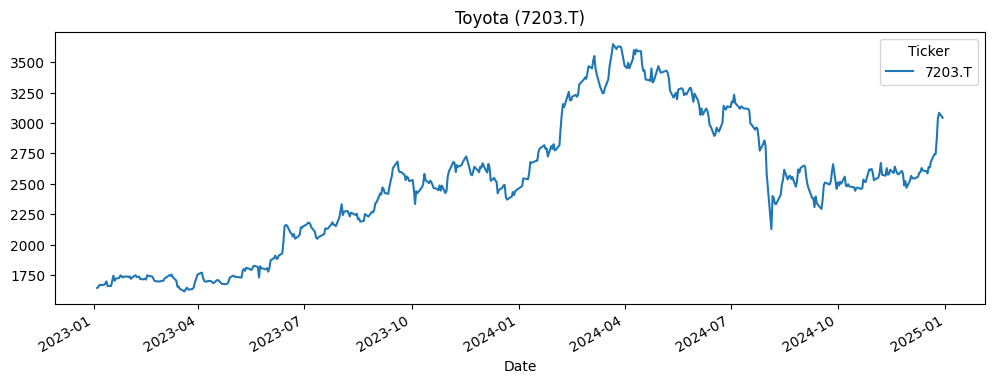

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt

# 下载丰田汽车数据（东证代码格式：数字+.T）
toyota = yf.download("7203.T", start="2023-01-01", end="2024-12-31")
print(toyota.tail())

# 画收盘价
toyota["Close"].plot(title="Toyota (7203.T)", figsize=(12,4))
plt.show()

In [ ]:
#红色蜡烛 = 收盘价 < 开盘价（下跌）
#绿色蜡烛 = 收盘价 > 开盘价（上涨）
#上下两根细线叫影线，代表当天的最高/最低价
#下方的柱状图是成交量，成交量越大说明参与买卖的人越多。

[*********************100%***********************]  1 of 1 completed


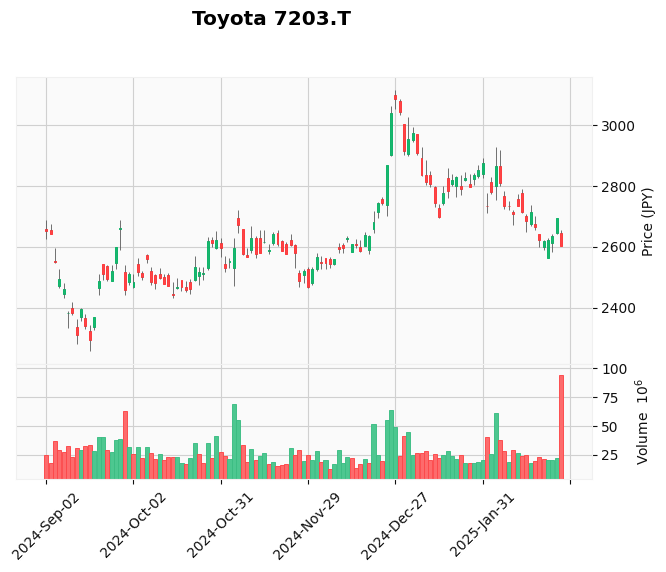

In [2]:
import yfinance as yf
import mplfinance as mpf

# 下载数据（取最近6个月，K线太多会看不清）
df = yf.download("7203.T", start="2024-09-01", end="2025-03-01")

# yfinance返回的列名有时是MultiIndex，需要压平
df.columns = df.columns.droplevel(1) if df.columns.nlevels > 1 else df.columns

# 画K线图（附成交量）
mpf.plot(
    df,
    type='candle',       # K线类型
    volume=True,         # 显示成交量
    style='yahoo',       # 样式
    title='Toyota 7203.T',
    ylabel='Price (JPY)',
)

In [ ]:
# 在K线图上叠加均线
# 均线（Moving Average）是最基础的量化信号，逻辑很简单：过去N天收盘价的平均值。
# 短期均线反应快，长期均线反应慢，两条线交叉时产生买卖信号。

[*********************100%***********************]  1 of 1 completed


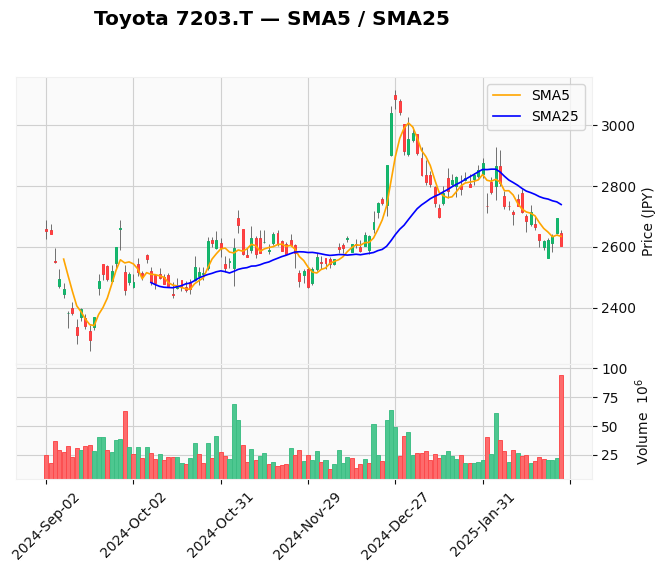

In [4]:
import yfinance as yf
import mplfinance as mpf

df = yf.download("7203.T", start="2024-09-01", end="2025-03-01")
df.columns = df.columns.droplevel(1) if df.columns.nlevels > 1 else df.columns

# 计算两条均线
df["SMA5"]  = df["Close"].rolling(window=5).mean()   # 5日均线（短期）
df["SMA25"] = df["Close"].rolling(window=25).mean()  # 25日均线（长期）

# 把均线作为附加图层传入
add_plots = [
    mpf.make_addplot(df["SMA5"],  color="orange", width=1.2, label="SMA5"),
    mpf.make_addplot(df["SMA25"], color="blue",   width=1.2, label="SMA25"),
]

mpf.plot(
    df,
    type='candle',
    volume=True,
    style='yahoo',
    title='Toyota 7203.T — SMA5 / SMA25',
    ylabel='Price (JPY)',
    addplot=add_plots,
)

In [ ]:
# SMA5（橙色）比SMA25（蓝色）抖动得多，这就是短期和长期的区别。
# 找一找图上有没有两条线交叉的地方——短期线从下往上穿过长期线叫"金叉"，是经典买入信号；反过来叫"死叉"，是卖出信号。

[*********************100%***********************]  1 of 1 completed


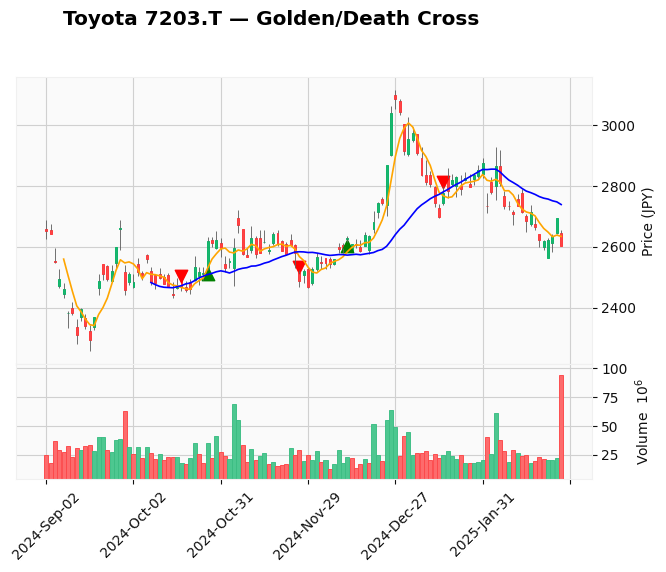

=== 金叉（买入信号）===
[Timestamp('2024-10-28 00:00:00'), Timestamp('2024-12-12 00:00:00')]

=== 死叉（卖出信号）===
[Timestamp('2024-10-18 00:00:00'), Timestamp('2024-11-27 00:00:00'), Timestamp('2025-01-20 00:00:00')]


In [5]:
import yfinance as yf
import mplfinance as mpf
import numpy as np

df = yf.download("7203.T", start="2024-09-01", end="2025-03-01")
df.columns = df.columns.droplevel(1) if df.columns.nlevels > 1 else df.columns

# 均线
df["SMA5"]  = df["Close"].rolling(5).mean()
df["SMA25"] = df["Close"].rolling(25).mean()

# 金叉/死叉检测
# SMA5がSMA25を下から上に抜けた日 → 金叉（買いシグナル）
# SMA5がSMA25を上から下に抜けた日 → 死叉（売りシグナル）
df["prev_diff"] = df["SMA5"].shift(1) - df["SMA25"].shift(1)
df["curr_diff"] = df["SMA5"] - df["SMA25"]

golden_cross = (df["prev_diff"] < 0) & (df["curr_diff"] > 0)
death_cross  = (df["prev_diff"] > 0) & (df["curr_diff"] < 0)

# 信号当天的价格位置（用于标记高低）
buy_signals  = np.where(golden_cross, df["Low"]  * 0.995, np.nan)
sell_signals = np.where(death_cross,  df["High"] * 1.005, np.nan)

# 附加图层
add_plots = [
    mpf.make_addplot(df["SMA5"],  color="orange", width=1.2),
    mpf.make_addplot(df["SMA25"], color="blue",   width=1.2),
    mpf.make_addplot(buy_signals,  type="scatter", markersize=80,
                     marker="^", color="green"),   # 金叉：绿色向上三角
    mpf.make_addplot(sell_signals, type="scatter", markersize=80,
                     marker="v", color="red"),     # 死叉：红色向下三角
]

mpf.plot(
    df,
    type='candle',
    volume=True,
    style='yahoo',
    title='Toyota 7203.T — Golden/Death Cross',
    ylabel='Price (JPY)',
    addplot=add_plots,
)

# 信号日期确认
print("=== 金叉（买入信号）===")
print(df[golden_cross].index.tolist())
print("\n=== 死叉（卖出信号）===")
print(df[death_cross].index.tolist())